<a href="https://colab.research.google.com/github/nbl-ahmd/project/blob/main/phase4_full_pipeline_inference_colab_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4: Full Prescription Inference Demo

This notebook runs the complete inference pipeline from full prescription images to OCR and lexicon-matched medication predictions.

Input: full prescription image(s).

Output: processed pages, region crops, line crops, word crops, OCR predictions, medicine lexicon matching, dosage/frequency extraction, overview images, CSV, and JSON.

## Step 1: Mount Drive, Pull Latest Code, and Enter Repo

In [3]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/nbl-ahmd/project.git'
DRIVE_BASE = Path('/content/drive/MyDrive/phase4_project')
REPO_DIR = DRIVE_BASE / 'repo'
IN_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    if not (REPO_DIR / 'pipeline').exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], check=False)
elif IN_KAGGLE:
    REPO_DIR = Path('/kaggle/working/project')
    if not (REPO_DIR / 'pipeline').exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], check=False)
else:
    REPO_DIR = Path.cwd()

os.chdir(REPO_DIR)
print('Repository:', Path.cwd())
print('IN_COLAB:', IN_COLAB, 'IN_KAGGLE:', IN_KAGGLE)
print('Has pipeline:', (Path.cwd() / 'pipeline').exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repository: /content/drive/MyDrive/phase4_project/repo
IN_COLAB: True IN_KAGGLE: False
Has pipeline: True


## Step 2: Install Dependencies

Use a GPU runtime for TrOCR inference if available. CPU works for a few words but will be slow.

In [4]:
!python3 -m pip install -q -r pipeline/requirements.txt
!python3 -m pip install -q -r pipeline/requirements-layout.txt
!python3 -m pip install -q -r pipeline/requirements-ocr.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.2 MB/s eta 0:00:00


## Step 3: Configure Input Images and Models

Put full prescription images in `data/full_inference_input/`, or change `INPUT_PATH` to one image file.

For final results, set `TROCR_MODEL` to your fine-tuned `best_model` folder. If no fine-tuned model is found, the notebook falls back to base TrOCR for testing only.

In [5]:
from pathlib import Path
import shutil
import zipfile

# Upload masked full prescription images here in Colab.
INPUT_PATH = Path('data/full_inference_input_masked')
INPUT_PATH.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path('data/full_pipeline_inference_demo')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional region detector. If missing, pipeline uses a heuristic region proposal.
REGION_MODEL = Path('models/region_yolo_best.pt')

# Your downloaded Kaggle best-model ZIP stored in Drive/repo.
TROCR_ZIP = Path('data/trocr model/phase4_trocr_best_model.zip')
TROCR_UNZIPPED_DIR = Path('data/trocr model/best_model')

# If the ZIP exists, unzip it once into a folder that transformers can load.
if TROCR_ZIP.exists():
    TROCR_UNZIPPED_DIR.mkdir(parents=True, exist_ok=True)
    required_model_file = TROCR_UNZIPPED_DIR / 'config.json'
    if not required_model_file.exists():
        print('Extracting TrOCR model ZIP:', TROCR_ZIP)
        with zipfile.ZipFile(TROCR_ZIP, 'r') as zf:
            zf.extractall(TROCR_UNZIPPED_DIR)
    else:
        print('TrOCR ZIP already extracted:', TROCR_UNZIPPED_DIR)
else:
    print('TrOCR ZIP not found at:', TROCR_ZIP)

# Fine-tuned TrOCR model candidates.
MODEL_CANDIDATES = [
    TROCR_UNZIPPED_DIR,
    Path('/content/drive/MyDrive/phase4_project/trocr_work/best_model'),
    Path('/kaggle/working/trocr_work/best_model'),
    Path('trocr_work/best_model'),
    Path('models/trocr_best_model'),
]
existing_models = [p for p in MODEL_CANDIDATES if (p / 'config.json').exists()]
TROCR_MODEL = str(existing_models[0]) if existing_models else 'microsoft/trocr-base-handwritten'

LEXICON_PATH = Path('pipeline/config/drug_lexicon.txt')

# Keep this lower for quick demos; use 2200 for final high-quality runs.
MAX_SIDE = 1600
NUM_BEAMS = 1
MAX_TARGET_LEN = 48

print('Input path:', INPUT_PATH.resolve())
print('Input image count:', len([p for p in INPUT_PATH.glob('*') if p.is_file()]))
print('Output dir:', OUTPUT_DIR.resolve())
print('Region model:', REGION_MODEL.resolve(), 'exists=', REGION_MODEL.exists())
print('TrOCR ZIP:', TROCR_ZIP.resolve(), 'exists=', TROCR_ZIP.exists())
print('TrOCR model:', TROCR_MODEL)
print('Lexicon:', LEXICON_PATH.resolve(), 'exists=', LEXICON_PATH.exists())

if TROCR_MODEL == 'microsoft/trocr-base-handwritten':
    print('WARNING: fine-tuned TrOCR model not found. Base TrOCR is only for testing, not final results.')


TrOCR ZIP already extracted: data/trocr model/best_model
Input path: /content/drive/MyDrive/phase4_project/repo/data/full_inference_input_masked
Input image count: 1
Output dir: /content/drive/MyDrive/phase4_project/repo/data/full_pipeline_inference_demo
Region model: /content/drive/MyDrive/phase4_project/repo/models/region_yolo_best.pt exists= True
TrOCR ZIP: /content/drive/MyDrive/phase4_project/repo/data/trocr model/phase4_trocr_best_model.zip exists= True
TrOCR model: data/trocr model/best_model
Lexicon: /content/drive/MyDrive/phase4_project/repo/pipeline/config/drug_lexicon.txt exists= True


## Step 4: Upload Full Prescription Images, If Needed

Run this cell in Colab if `data/full_inference_input/` is empty.

In [6]:
# Upload masked full prescription image(s) for inference.
# This cell always offers upload in Colab. Re-run it when you want to add more images.

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}

CLEAR_OLD_INPUTS = True  # set False if you want to keep previous uploaded images
if CLEAR_OLD_INPUTS:
    for p in INPUT_PATH.glob('*'):
        if p.is_file():
            p.unlink()

if IN_COLAB:
    from google.colab import files
    print('Upload masked full prescription image(s).')
    uploaded = files.upload()
    for name, content in uploaded.items():
        out = INPUT_PATH / name
        out.write_bytes(content)
    print('Uploaded files:', list(uploaded.keys()))
else:
    print('Not running in Colab. Put images manually in:', INPUT_PATH)

image_files = [p for p in sorted(INPUT_PATH.glob('*')) if p.suffix.lower() in VALID_EXTS]
print('Images ready for inference:', len(image_files))
for p in image_files:
    print('-', p)


Upload masked full prescription image(s).


Saving 9.jpg to 9 (1).jpg
Uploaded files: ['9 (1).jpg']
Images ready for inference: 1
- data/full_inference_input_masked/9 (1).jpg


## Step 5: Preview Input Images

data/full_inference_input_masked/9 (1).jpg


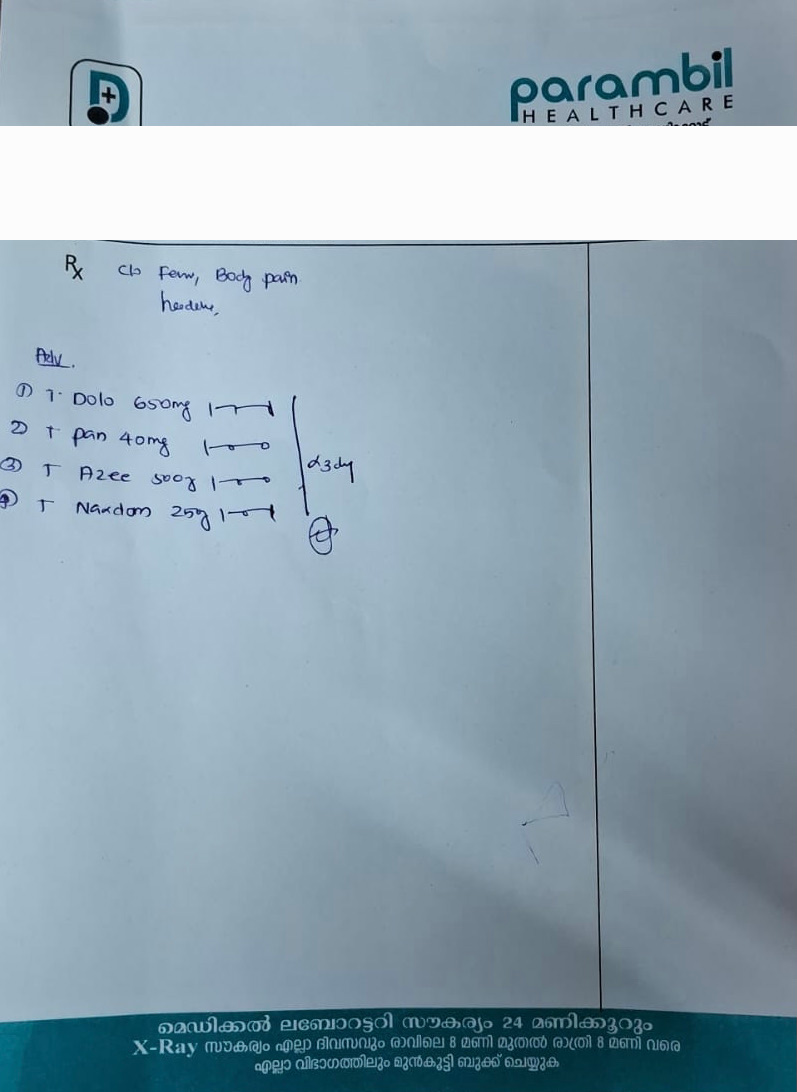

In [7]:
from IPython.display import display, Image as IPImage

image_files = [p for p in sorted(INPUT_PATH.glob('*')) if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff']]
if not image_files:
    raise FileNotFoundError(f'No input images found in {INPUT_PATH}. Upload images or update INPUT_PATH.')

for p in image_files[:5]:
    print(p)
    display(IPImage(filename=str(p), width=700))

## Step 6: Run Full Pipeline Inference

This runs:

full image -> preprocessing -> region crop -> line segmentation -> word segmentation -> TrOCR OCR -> lexicon/dosage/frequency validation.

In [8]:
import subprocess

if TROCR_MODEL == 'microsoft/trocr-base-handwritten':
    raise RuntimeError('Fine-tuned TrOCR model not found. Check TROCR_ZIP path or unzip model folder before final inference.')

image_files = [p for p in sorted(INPUT_PATH.glob('*')) if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff']]
if not image_files:
    raise FileNotFoundError(f'No input images found in {INPUT_PATH}. Run the upload cell first.')

cmd = [
    'python3', 'pipeline/scripts/run_end_to_end.py',
    '--input', str(INPUT_PATH),
    '--output-dir', str(OUTPUT_DIR),
    '--ocr-backend', 'trocr',
    '--ocr-unit', 'word',
    '--trocr-model', str(TROCR_MODEL),
    '--max-target-len', str(MAX_TARGET_LEN),
    '--num-beams', str(NUM_BEAMS),
    '--line-padding', '6',
    '--max-side', str(MAX_SIDE),
    '--lexicon', str(LEXICON_PATH),
]

if REGION_MODEL.exists():
    cmd += ['--yolo-model', str(REGION_MODEL), '--target-class', '0']
else:
    print('Region model missing. Using heuristic region proposal fallback.')

print('Running command:')
print(' '.join(cmd))
subprocess.run(cmd, check=True)


Running command:
python3 pipeline/scripts/run_end_to_end.py --input data/full_inference_input_masked --output-dir data/full_pipeline_inference_demo --ocr-backend trocr --ocr-unit word --trocr-model data/trocr model/best_model --max-target-len 48 --num-beams 1 --line-padding 6 --max-side 1600 --lexicon pipeline/config/drug_lexicon.txt --yolo-model models/region_yolo_best.pt --target-class 0


CompletedProcess(args=['python3', 'pipeline/scripts/run_end_to_end.py', '--input', 'data/full_inference_input_masked', '--output-dir', 'data/full_pipeline_inference_demo', '--ocr-backend', 'trocr', '--ocr-unit', 'word', '--trocr-model', 'data/trocr model/best_model', '--max-target-len', '48', '--num-beams', '1', '--line-padding', '6', '--max-side', '1600', '--lexicon', 'pipeline/config/drug_lexicon.txt', '--yolo-model', 'models/region_yolo_best.pt', '--target-class', '0'], returncode=0)

## Step 7: Load Output Tables

In [9]:
import pandas as pd

page_manifest = OUTPUT_DIR / 'page_manifest.csv'
region_manifest = OUTPUT_DIR / 'region_manifest.csv'
line_manifest = OUTPUT_DIR / 'line_manifest.csv'
word_manifest = OUTPUT_DIR / 'word_manifest.csv'
review_csv = OUTPUT_DIR / 'segmentation_review.csv'
pred_csv = OUTPUT_DIR / 'predictions.csv'
filtered_csv = OUTPUT_DIR / 'medicine_dosage_predictions.csv'
line_pred_csv = OUTPUT_DIR / 'line_predictions.csv'
line_filtered_csv = OUTPUT_DIR / 'line_medicine_dosage_predictions.csv'

pages = pd.read_csv(page_manifest) if page_manifest.exists() else pd.DataFrame()
regions = pd.read_csv(region_manifest) if region_manifest.exists() else pd.DataFrame()
lines = pd.read_csv(line_manifest) if line_manifest.exists() else pd.DataFrame()
words = pd.read_csv(word_manifest) if word_manifest.exists() else pd.DataFrame()
review = pd.read_csv(review_csv) if review_csv.exists() else pd.DataFrame()
pred = pd.read_csv(pred_csv) if pred_csv.exists() else pd.DataFrame()
medicine_pred = pd.read_csv(filtered_csv) if filtered_csv.exists() else pd.DataFrame()
line_pred = pd.read_csv(line_pred_csv) if line_pred_csv.exists() else pd.DataFrame()
line_medicine_pred = pd.read_csv(line_filtered_csv) if line_filtered_csv.exists() else pd.DataFrame()

print('Pages:', len(pages))
print('Regions:', len(regions))
print('Lines:', len(lines))
print('Words:', len(words))
print('All OCR predictions:', len(pred))
print('Word-level medicine/dosage rows kept:', len(medicine_pred))
print('Line-wise corrected medicine/dosage rows kept:', len(line_medicine_pred))

display(line_medicine_pred.head(50))


Pages: 1
Regions: 1
Lines: 5
Words: 28
All OCR predictions: 28
Word-level medicine/dosage rows kept: 7
Line-wise corrected medicine/dosage rows kept: 2


,page_id,region_id,line_id,line_image_path,line_context_image_path,line_ocr_text,medicine_name,medicine_match_score,matched_candidate,dosage,frequency,route,final_corrected_text,validation_status
0,9_1,9_1_r00,9_1_r00_l00,data/full_pipeline_inference_demo/line_crops/l...,data/full_pipeline_inference_demo/line_crops/c...,R Clo Fenadin Prun,Fenadin,1.0,Fenadin,NaN,NaN,NaN,Fenadin,matched
1,9_1,9_1_r00,9_1_r00_l02,data/full_pipeline_inference_demo/line_crops/l...,data/full_pipeline_inference_demo/line_crops/c...,B D D D T T 7- T Pan Dolo Naxum Azce toms Geso...,Lumona,1.0,Lumona,25mg,NaN,NaN,Lumona 25mg,matched


## Step 8: Show Segmentation Overview Images

Overview folder: data/full_pipeline_inference_demo/segmentation_overview
Line overviews
data/full_pipeline_inference_demo/segmentation_overview/5_r00_line_overview.png


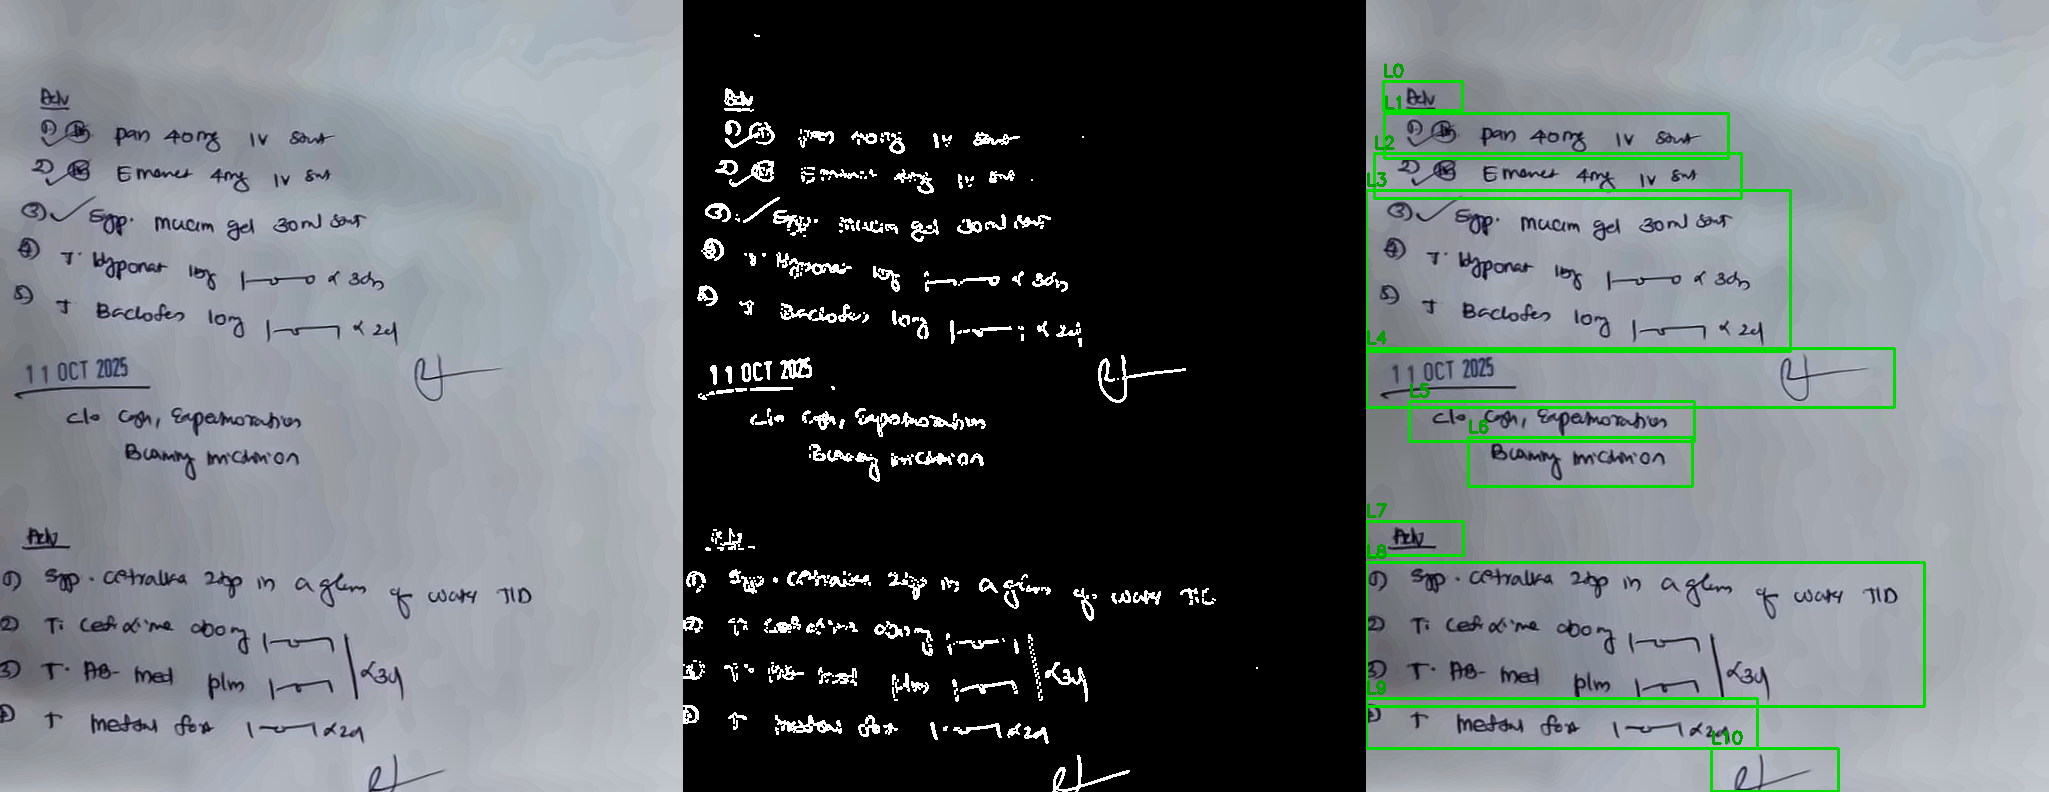

data/full_pipeline_inference_demo/segmentation_overview/9_1_r00_line_overview.png


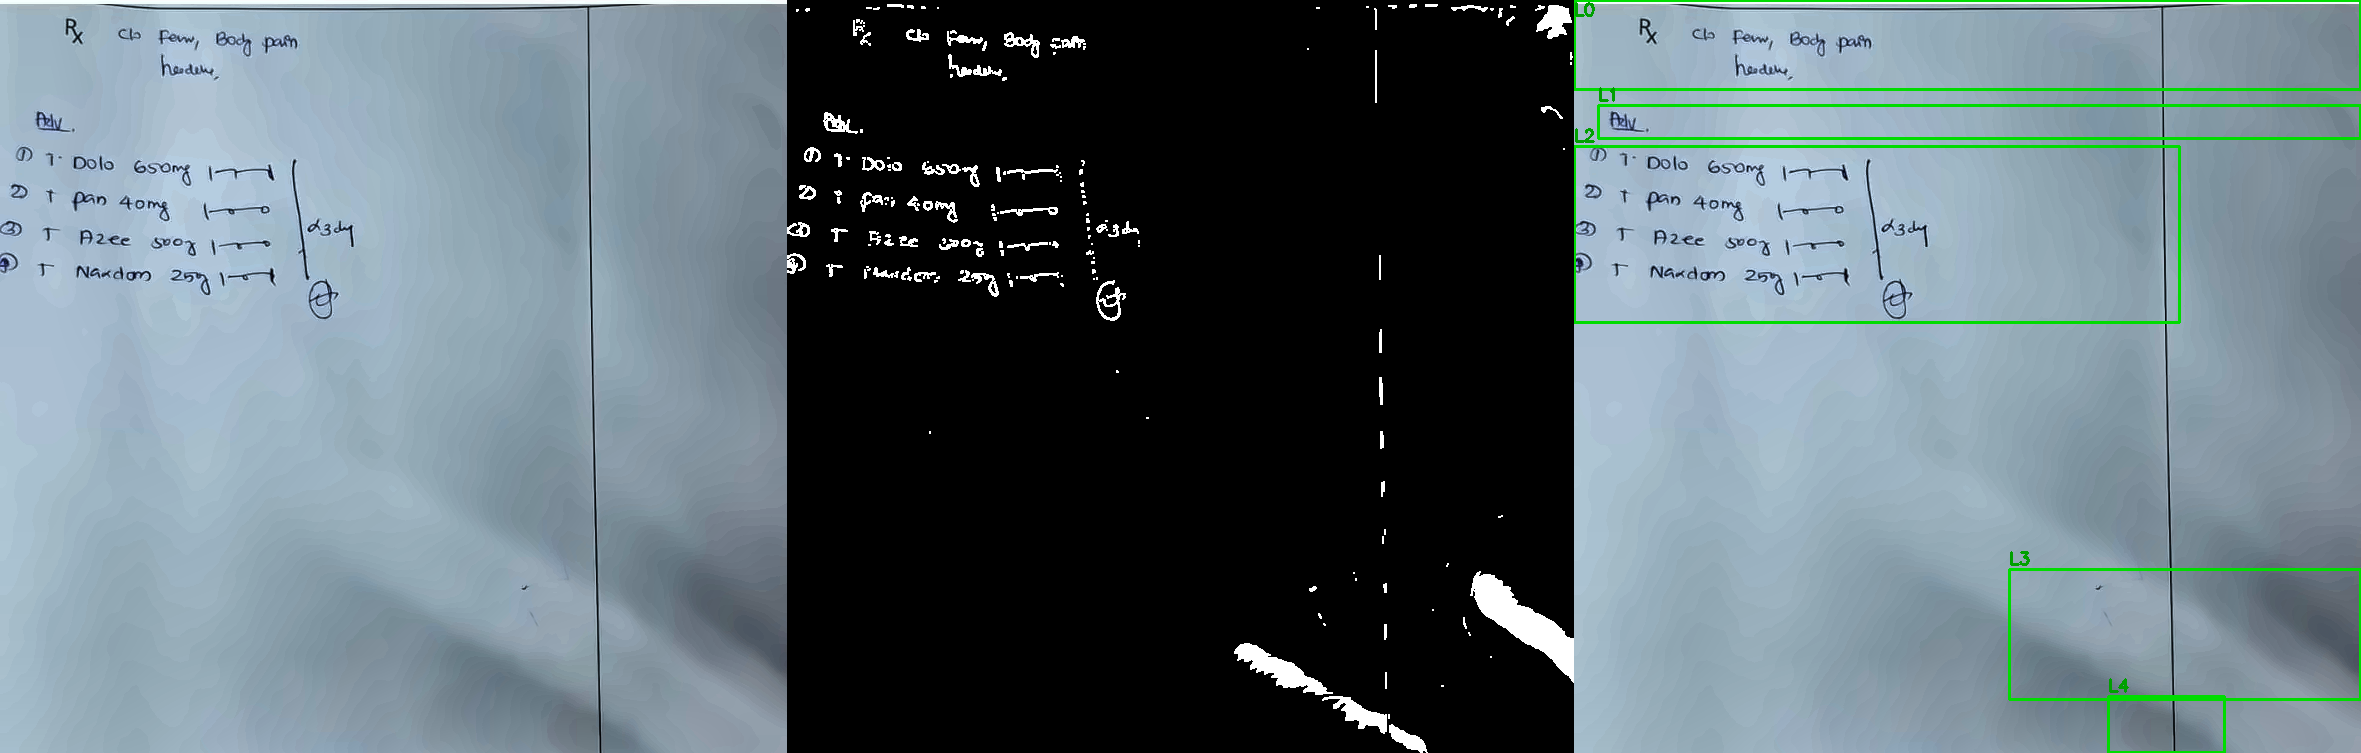

data/full_pipeline_inference_demo/segmentation_overview/9_r00_line_overview.png


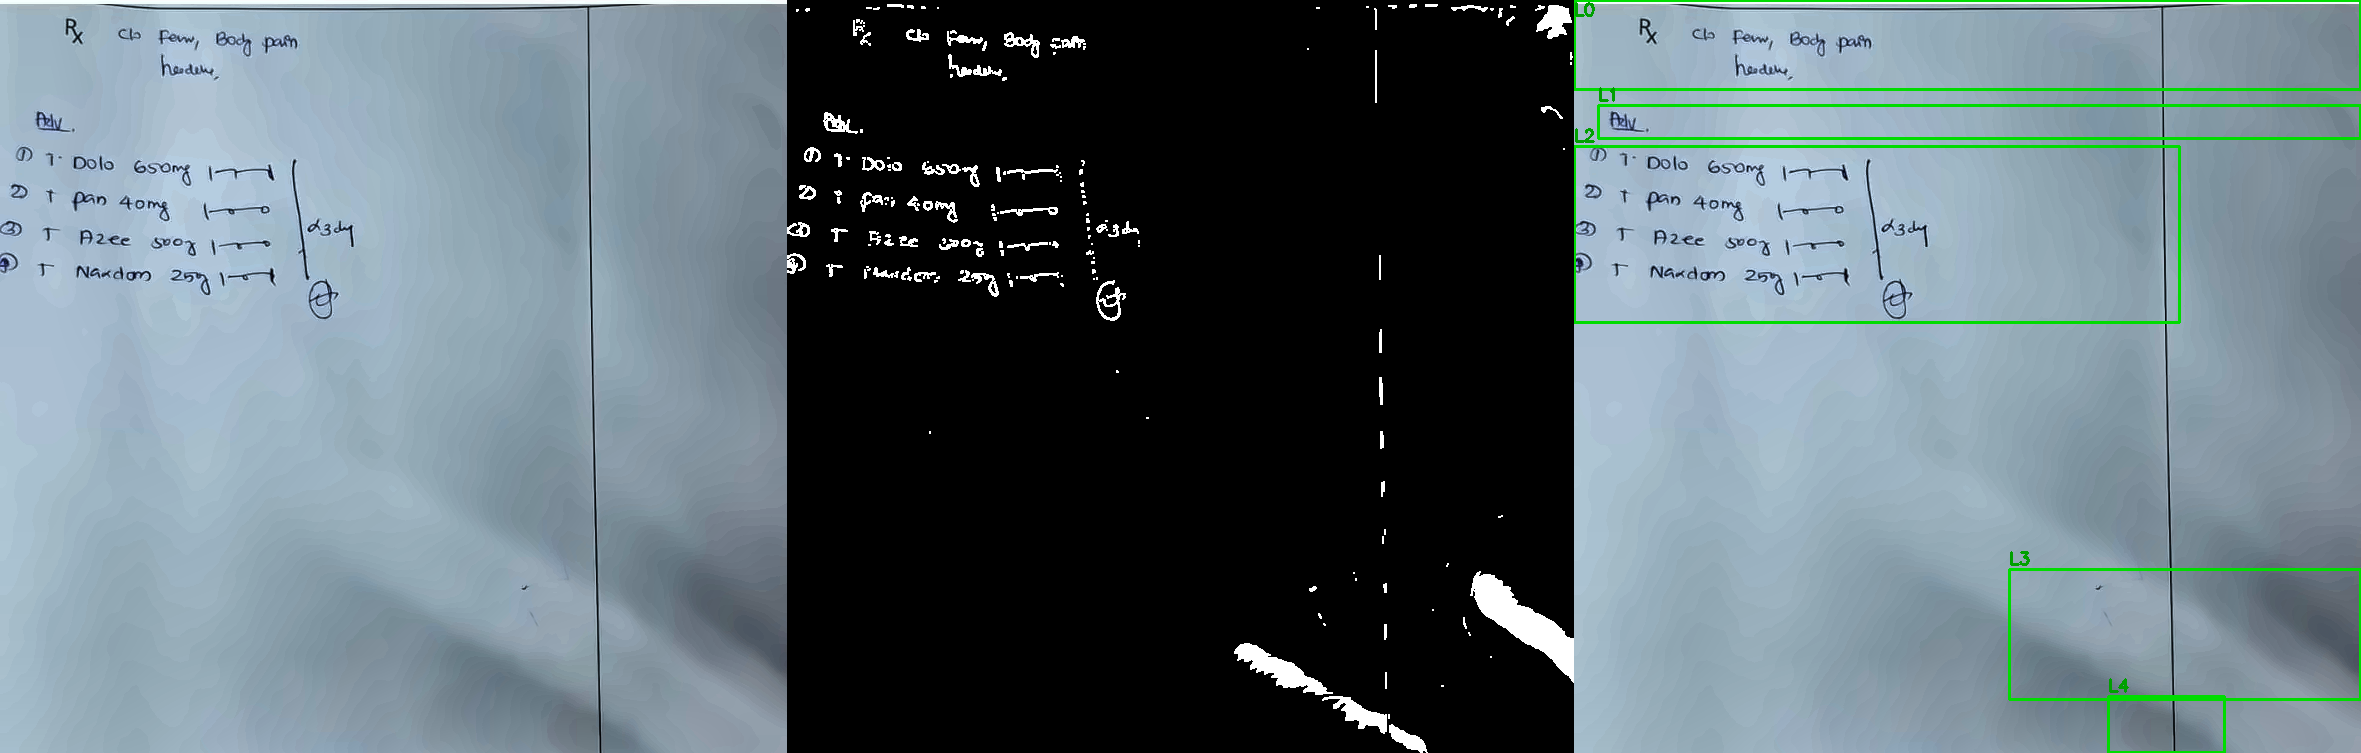

Word overviews
data/full_pipeline_inference_demo/segmentation_overview/5_r00_l00_word_overview.png


data/full_pipeline_inference_demo/segmentation_overview/5_r00_l01_word_overview.png


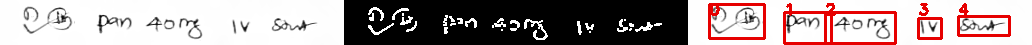

data/full_pipeline_inference_demo/segmentation_overview/5_r00_l02_word_overview.png


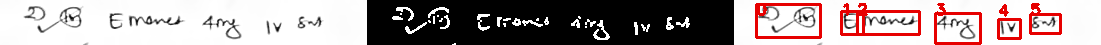

data/full_pipeline_inference_demo/segmentation_overview/5_r00_l03_word_overview.png


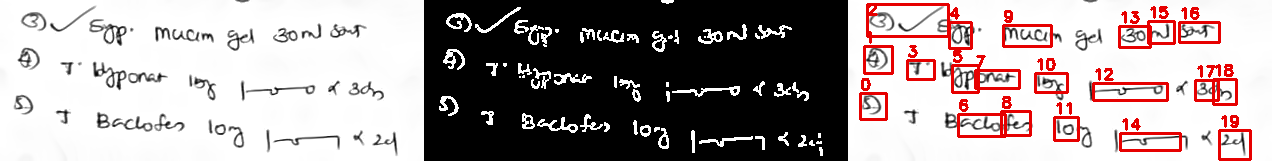

data/full_pipeline_inference_demo/segmentation_overview/5_r00_l04_word_overview.png


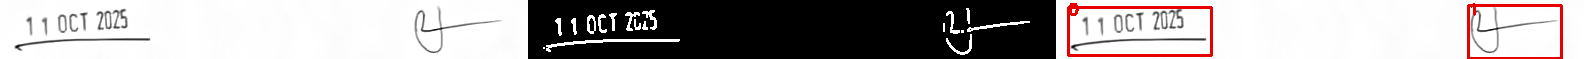

data/full_pipeline_inference_demo/segmentation_overview/5_r00_l05_word_overview.png


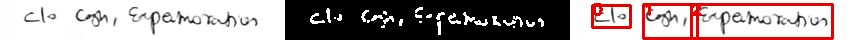

data/full_pipeline_inference_demo/segmentation_overview/5_r00_l06_word_overview.png


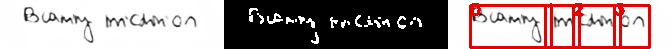

data/full_pipeline_inference_demo/segmentation_overview/5_r00_l07_word_overview.png


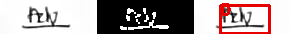

In [10]:
overview_dir = OUTPUT_DIR / 'segmentation_overview'
print('Overview folder:', overview_dir)

print('Line overviews')
for p in sorted(overview_dir.glob('*line_overview.png'))[:5]:
    print(p)
    display(IPImage(filename=str(p), width=950))

print('Word overviews')
for p in sorted(overview_dir.glob('*word_overview.png'))[:8]:
    print(p)
    display(IPImage(filename=str(p), width=950))

## Step 9: Show Line-Wise Corrected OCR Results


Final line-wise corrected medicine/dosage results


,page_id,region_id,line_id,line_image_path,line_ocr_text,medicine_name,medicine_match_score,matched_candidate,dosage,frequency,route,final_corrected_text,validation_status
0,9_1,9_1_r00,9_1_r00_l00,data/full_pipeline_inference_demo/line_crops/l...,R Clo Fenadin Prun,Fenadin,1.0,Fenadin,NaN,NaN,NaN,Fenadin,matched
1,9_1,9_1_r00,9_1_r00_l02,data/full_pipeline_inference_demo/line_crops/l...,B D D D T T 7- T Pan Dolo Naxum Azce toms Geso...,Lumona,1.0,Lumona,25mg,NaN,NaN,Lumona 25mg,matched


OCR: R Clo Fenadin Prun
Final: Fenadin


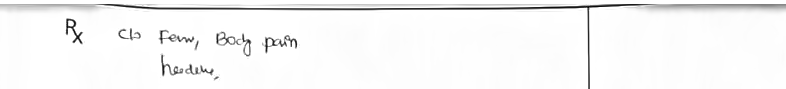

OCR: B D D D T T 7- T Pan Dolo Naxum Azce toms Gesomg Suox 25mg D to 1-1 Ito 1-1 C Lumona
Final: Lumona 25mg


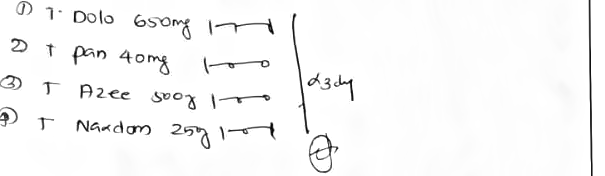

Word-level medicine/dosage rows


,page_id,region_id,line_id,word_id,image_path,ocr_text,medicine_name,medicine_match_score,matched_candidate,dosage,frequency,route,validation_status
0,9_1,9_1_r00,9_1_r00_l00,9_1_r00_l00_w02,data/full_pipeline_inference_demo/line_crops/w...,Fenadin,Fenadin,1.0000,Fenadin,NaN,NaN,NaN,matched
1,9_1,9_1_r00,9_1_r00_l02,9_1_r00_l02_w08,data/full_pipeline_inference_demo/line_crops/w...,Pan,Pan,1.0000,Pan,NaN,NaN,NaN,matched
2,9_1,9_1_r00,9_1_r00_l02,9_1_r00_l02_w09,data/full_pipeline_inference_demo/line_crops/w...,Dolo,Dolo,1.0000,Dolo,NaN,NaN,NaN,matched
3,9_1,9_1_r00,9_1_r00_l02,9_1_r00_l02_w10,data/full_pipeline_inference_demo/line_crops/w...,Naxum,Nexum,0.8000,Naxum,NaN,NaN,NaN,matched
4,9_1,9_1_r00,9_1_r00_l02,9_1_r00_l02_w11,data/full_pipeline_inference_demo/line_crops/w...,Azce,Ace,0.8571,Azce,NaN,NaN,NaN,matched
5,9_1,9_1_r00,9_1_r00_l02,9_1_r00_l02_w15,data/full_pipeline_inference_demo/line_crops/w...,25mg,NaN,0.0000,NaN,25mg,NaN,NaN,dose_only
6,9_1,9_1_r00,9_1_r00_l02,9_1_r00_l02_w22,data/full_pipeline_inference_demo/line_crops/w...,Lumona,Lumona,1.0000,Lumona,NaN,NaN,NaN,matched


Matched medicine lines: 2
Dosage/frequency-only lines: 0


In [11]:
from IPython.display import display, Image as IPImage

if pred.empty:
    raise RuntimeError('No predictions found. Check the inference command output above.')

word_cols = ['page_id', 'region_id', 'line_id', 'word_id', 'image_path', 'ocr_text', 'medicine_name', 'medicine_match_score', 'matched_candidate', 'dosage', 'frequency', 'route', 'validation_status']
line_cols = ['page_id', 'region_id', 'line_id', 'line_image_path', 'line_ocr_text', 'medicine_name', 'medicine_match_score', 'matched_candidate', 'dosage', 'frequency', 'route', 'final_corrected_text', 'validation_status']

print('Final line-wise corrected medicine/dosage results')
if line_medicine_pred.empty:
    print('No corrected medicine/dosage lines were kept. Check segmentation/OCR output and lexicon coverage.')
else:
    display(line_medicine_pred[[c for c in line_cols if c in line_medicine_pred.columns]].head(80))
    for _, row in line_medicine_pred.head(12).iterrows():
        print('OCR:', row.get('line_ocr_text', ''))
        print('Final:', row.get('final_corrected_text', ''))
        img_path = Path(str(row.get('line_image_path', '')))
        if img_path.exists():
            display(IPImage(filename=str(img_path), width=760))

print('Word-level medicine/dosage rows')
if medicine_pred.empty:
    print('No word-level medicine/dosage rows were kept.')
else:
    display(medicine_pred[[c for c in word_cols if c in medicine_pred.columns]].head(80))

matched = line_medicine_pred[line_medicine_pred['validation_status'].astype(str) == 'matched'].copy() if 'validation_status' in line_medicine_pred.columns else pd.DataFrame()
dose_only = line_medicine_pred[line_medicine_pred['validation_status'].astype(str) == 'dose_only'].copy() if 'validation_status' in line_medicine_pred.columns else pd.DataFrame()
print('Matched medicine lines:', len(matched))
print('Dosage/frequency-only lines:', len(dose_only))


## Step 10: Create Line-Wise Corrected Demo Grid


Saved: data/full_pipeline_inference_demo/demo_preview/full_pipeline_linewise_corrected_grid.png


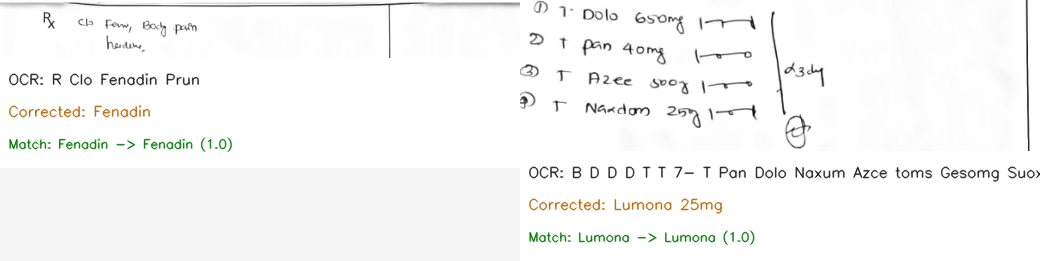

In [12]:
import math
import cv2
import numpy as np

preview_dir = OUTPUT_DIR / 'demo_preview'
preview_dir.mkdir(parents=True, exist_ok=True)

preview_source = line_medicine_pred if not line_medicine_pred.empty else (medicine_pred if not medicine_pred.empty else pred.head(30))

def row_value(row, *names):
    for name in names:
        if name in row and pd.notna(row[name]):
            return str(row[name])
    return ''

def make_card(row):
    image_path = Path(row_value(row, 'line_image_path', 'image_path'))
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    target_w = 520 if 'line_image_path' in row.index else 360
    scale = target_w / max(1, w)
    resized = cv2.resize(img, (target_w, max(40, int(h * scale))), interpolation=cv2.INTER_AREA)
    canvas = np.full((resized.shape[0] + 110, target_w, 3), 255, dtype=np.uint8)
    canvas[:resized.shape[0], :, :] = resized
    ocr_text = row_value(row, 'line_ocr_text', 'ocr_text')
    final_text = row_value(row, 'final_corrected_text')
    if not final_text:
        final_text = f"{row_value(row, 'medicine_name')} {row_value(row, 'dosage')} {row_value(row, 'frequency')}".strip()
    score = row_value(row, 'medicine_match_score')
    line1 = f"OCR: {ocr_text}"[:62]
    line2 = f"Corrected: {final_text}"[:62]
    line3 = f"Match: {row_value(row, 'matched_candidate')} -> {row_value(row, 'medicine_name')} ({score})"[:62]
    y0 = resized.shape[0]
    cv2.putText(canvas, line1, (8, y0 + 26), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (25, 25, 25), 1, cv2.LINE_AA)
    cv2.putText(canvas, line2, (8, y0 + 58), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0, 100, 180), 1, cv2.LINE_AA)
    cv2.putText(canvas, line3, (8, y0 + 90), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 120, 0), 1, cv2.LINE_AA)
    return canvas

cards = []
for _, row in preview_source.head(24).iterrows():
    card = make_card(row)
    if card is not None:
        cards.append(card)

if cards:
    cols = 2 if cards[0].shape[1] > 400 else 3
    card_h = max(c.shape[0] for c in cards)
    card_w = cards[0].shape[1]
    rows_n = math.ceil(len(cards) / cols)
    grid = np.full((rows_n * card_h, cols * card_w, 3), 245, dtype=np.uint8)
    for idx, card in enumerate(cards):
        y = (idx // cols) * card_h
        x = (idx % cols) * card_w
        grid[y:y+card.shape[0], x:x+card.shape[1]] = card
    preview_path = preview_dir / 'full_pipeline_linewise_corrected_grid.png'
    cv2.imwrite(str(preview_path), grid)
    print('Saved:', preview_path)
    display(IPImage(filename=str(preview_path), width=1100))
else:
    print('No cards created.')


## Step 11: Final Output Summary


In [13]:
print('Final output folder:', OUTPUT_DIR)
print('All predictions CSV:', OUTPUT_DIR / 'predictions.csv')
print('Word-level medicine/dosage CSV:', OUTPUT_DIR / 'medicine_dosage_predictions.csv')
print('Line-wise corrected CSV:', OUTPUT_DIR / 'line_medicine_dosage_predictions.csv')
print('Line-wise corrected JSON:', OUTPUT_DIR / 'line_medicine_dosage_predictions.json')
print('All line predictions CSV:', OUTPUT_DIR / 'line_predictions.csv')
print('Predictions JSON:', OUTPUT_DIR / 'predictions.json')
print('Segmentation overview images:', OUTPUT_DIR / 'segmentation_overview')
print('Line-wise demo grid:', OUTPUT_DIR / 'demo_preview' / 'full_pipeline_linewise_corrected_grid.png')

if 'validation_status' in pred.columns:
    print('All OCR row status counts')
    display(pred['validation_status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count'))
if 'validation_status' in line_medicine_pred.columns:
    print('Kept line-wise medicine/dosage status counts')
    display(line_medicine_pred['validation_status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count'))
if not review.empty:
    display(review.head(30))


Final output folder: data/full_pipeline_inference_demo
All predictions CSV: data/full_pipeline_inference_demo/predictions.csv
Word-level medicine/dosage CSV: data/full_pipeline_inference_demo/medicine_dosage_predictions.csv
Line-wise corrected CSV: data/full_pipeline_inference_demo/line_medicine_dosage_predictions.csv
Line-wise corrected JSON: data/full_pipeline_inference_demo/line_medicine_dosage_predictions.json
All line predictions CSV: data/full_pipeline_inference_demo/line_predictions.csv
Predictions JSON: data/full_pipeline_inference_demo/predictions.json
Segmentation overview images: data/full_pipeline_inference_demo/segmentation_overview
Line-wise demo grid: data/full_pipeline_inference_demo/demo_preview/full_pipeline_linewise_corrected_grid.png
All OCR row status counts


,status,count
0,ignored_non_medicine,21
1,matched,6
2,dose_only,1


Kept line-wise medicine/dosage status counts


,status,count
0,matched,2


,page_id,region_id,line_id,stage,detected_count,method,quality_flag,rejected_tiny_components,notes
0,9_1,9_1_r00,NaN,line,5,hybrid_projection_seam_refined,ok,17.0,projection:5;components:4;connected:4
1,9_1,9_1_r00,9_1_r00_l00,word,4,hybrid_components_gap_valley,ok,NaN,word_count=4
2,9_1,9_1_r00,9_1_r00_l01,word,1,hybrid_components_gap_valley,ok,NaN,word_count=1
3,9_1,9_1_r00,9_1_r00_l02,word,23,hybrid_components_gap_valley,ok,NaN,word_count=23
4,9_1,9_1_r00,9_1_r00_l03,word,0,hybrid_components_gap_valley,no_words_detected,NaN,word_count=0
5,9_1,9_1_r00,9_1_r00_l04,word,0,hybrid_components_gap_valley,no_words_detected,NaN,word_count=0


## Optional: Random TrOCR Test-Crop Inference

Run this to test only the TrOCR model on random cropped word images from the combined dataset test split. This does not use full-page segmentation.


The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

000136_rxhand.jpg | label: Paloxi | pred: Paloxi


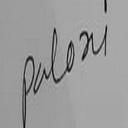

000628_rxhand.jpg | label: tab | pred: tab


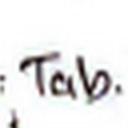

000184_bd_validation.png | label: Trilock | pred: Trilock


000031_bd_training.png | label: Azithrocin | pred: Azithrocin


000677_rxhand.jpg | label: monfast | pred: monfast


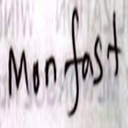

,IMAGE,label,prediction,correct
0,000136_rxhand.jpg,Paloxi,Paloxi,True
1,000628_rxhand.jpg,tab,tab,True
2,000184_bd_validation.png,Trilock,Trilock,True
3,000031_bd_training.png,Azithrocin,Azithrocin,True
4,000677_rxhand.jpg,monfast,monfast,True


In [15]:
import random
import json
from tqdm.auto import tqdm
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from IPython.display import display, Image as IPImage

TEST_DATASET_CANDIDATES = [
    Path('data/combined_trocr_word_dataset/Testing'),
    Path('/content/drive/MyDrive/phase4_project/repo/data/raw/combined_trocr_word_dataset/Testing'),
    Path('/kaggle/input/handwritten-prescription/combined_trocr_word_dataset/Testing'),
    Path('/kaggle/input/handwritten-prescription/data/combined_trocr_word_dataset/Testing'),
]
TEST_BASE = next((p for p in TEST_DATASET_CANDIDATES if (p / 'testing_labels.csv').exists()), None)
if TEST_BASE is None:
    raise FileNotFoundError('Could not find combined_trocr_word_dataset/Testing. Update TEST_DATASET_CANDIDATES.')

labels_csv = TEST_BASE / 'testing_labels.csv'
words_dir = TEST_BASE / 'testing_words'
test_labels = pd.read_csv(labels_csv)

sample_n = min(5, len(test_labels))
sample_df = test_labels.sample(sample_n, random_state=42).reset_index(drop=True)

processor = TrOCRProcessor.from_pretrained(str(TROCR_MODEL))
model = VisionEncoderDecoderModel.from_pretrained(str(TROCR_MODEL)).to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
device = next(model.parameters()).device

def norm_text(x):
    return ' '.join(str(x).strip().split())

def predict_crop(path):
    image = Image.open(path).convert('RGB')
    pixel_values = processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pixel_values, max_length=MAX_TARGET_LEN, num_beams=NUM_BEAMS, early_stopping=NUM_BEAMS > 1)
    return norm_text(processor.batch_decode(ids, skip_special_tokens=True)[0])

rows = []
for _, row in sample_df.iterrows():
    img_name = str(row['IMAGE'])
    img_path = words_dir / img_name
    pred_text = predict_crop(img_path)
    label = norm_text(row['MEDICINE_NAME'])
    rows.append({'IMAGE': img_name, 'label': label, 'prediction': pred_text, 'correct': label == pred_text})
    print(img_name, '| label:', label, '| pred:', pred_text)
    display(IPImage(filename=str(img_path), width=240))

random_crop_pred_df = pd.DataFrame(rows)
display(random_crop_pred_df)


## Optional: TrOCR Test Metrics on Combined Test Split

Runs model inference on the combined cropped-word test split and prints exact match, case-insensitive exact match, CER, and WER. Set `MAX_TEST_SAMPLES = None` for the full test split.


In [16]:
MAX_TEST_SAMPLES = 200  # set None for full test split

metric_df = test_labels.copy()
if MAX_TEST_SAMPLES is not None:
    metric_df = metric_df.sample(min(MAX_TEST_SAMPLES, len(metric_df)), random_state=123).reset_index(drop=True)

metric_rows = []
for _, row in tqdm(metric_df.iterrows(), total=len(metric_df)):
    img_name = str(row['IMAGE'])
    label = norm_text(row['MEDICINE_NAME'])
    pred_text = predict_crop(words_dir / img_name)
    metric_rows.append({'IMAGE': img_name, 'label': label, 'prediction': pred_text})

metric_out = pd.DataFrame(metric_rows)

def edit_distance(a, b):
    a = list(a)
    b = list(b)
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a) + 1):
        dp[i][0] = i
    for j in range(len(b) + 1):
        dp[0][j] = j
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)
    return dp[-1][-1]

strict = (metric_out['label'] == metric_out['prediction']).mean()
case_insensitive = (metric_out['label'].str.lower() == metric_out['prediction'].str.lower()).mean()
char_edits = sum(edit_distance(p, y) for p, y in zip(metric_out['prediction'], metric_out['label']))
char_total = sum(max(1, len(y)) for y in metric_out['label'])
word_edits = sum(edit_distance(p.split(), y.split()) for p, y in zip(metric_out['prediction'], metric_out['label']))
word_total = sum(max(1, len(y.split())) for y in metric_out['label'])
cer = char_edits / char_total
wer = word_edits / word_total

metrics = {
    'samples': len(metric_out),
    'strict_exact_match_percent': round(strict * 100, 2),
    'case_insensitive_exact_match_percent': round(case_insensitive * 100, 2),
    'cer_percent': round(cer * 100, 2),
    'wer_percent': round(wer * 100, 2),
}
print(metrics)
display(metric_out.assign(correct=metric_out['label'] == metric_out['prediction']).head(50))

metrics_path = OUTPUT_DIR / 'trocr_test_metrics.json'
preds_path = OUTPUT_DIR / 'trocr_test_predictions_sample.csv'
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
metric_out.to_csv(preds_path, index=False)
print('Saved metrics:', metrics_path)
print('Saved predictions:', preds_path)


  0%|          | 0/200 [00:00<?, ?it/s]

{'samples': 200, 'strict_exact_match_percent': np.float64(80.0), 'case_insensitive_exact_match_percent': np.float64(85.0), 'cer_percent': 9.5, 'wer_percent': 21.56}


,IMAGE,label,prediction,correct
0,000318_bd_testing.png,Montair,Montair,True
1,000235_rxhand.jpg,Maxima,Maxima,True
2,000449_bd_validation.png,Bacaid,Bacaid,True
3,000739_bd_training.png,Cetisoft,Cetisoft,True
4,000621_rxhand.jpg,Syrup,Syrup,True
5,000210_bd_training.png,Alatrol,Alatrol,True
6,000981_rxhand.jpg,beklo,Beklo,False
7,000103_rxhand.jpg,Protio,probio,False
8,000395_bd_training.png,Dancel,Dancel,True
9,000013_rxhand.jpg,Omeprazole,omeprazole,False


Saved metrics: data/full_pipeline_inference_demo/trocr_test_metrics.json
Saved predictions: data/full_pipeline_inference_demo/trocr_test_predictions_sample.csv


In [17]:
# Presentation-ready metrics table

import pandas as pd
from IPython.display import display

metrics_table = pd.DataFrame([
    {
        "Metric": "Test samples evaluated",
        "Value": metrics["samples"],
        "Meaning": "Number of cropped word images used for this evaluation",
    },
    {
        "Metric": "Strict Exact-Match Accuracy",
        "Value": f'{metrics["strict_exact_match_percent"]:.2f}%',
        "Meaning": "Prediction must exactly match the label",
    },
    {
        "Metric": "Case-Insensitive Exact-Match Accuracy",
        "Value": f'{metrics["case_insensitive_exact_match_percent"]:.2f}%',
        "Meaning": "Same as exact match, but ignores uppercase/lowercase difference",
    },
    {
        "Metric": "Character Error Rate (CER)",
        "Value": f'{metrics["cer_percent"]:.2f}%',
        "Meaning": "Character-level edit distance; lower is better",
    },
    {
        "Metric": "Word Error Rate (WER)",
        "Value": f'{metrics["wer_percent"]:.2f}%',
        "Meaning": "Word-level edit distance; lower is better",
    },
])

display(metrics_table)

metrics_table_path = OUTPUT_DIR / "trocr_metrics_table.csv"
metrics_table.to_csv(metrics_table_path, index=False)
print("Saved metrics table:", metrics_table_path)

,Metric,Value,Meaning
0,Test samples evaluated,200,Number of cropped word images used for this ev...
1,Strict Exact-Match Accuracy,80.00%,Prediction must exactly match the label
2,Case-Insensitive Exact-Match Accuracy,85.00%,"Same as exact match, but ignores uppercase/low..."
3,Character Error Rate (CER),9.50%,Character-level edit distance; lower is better
4,Word Error Rate (WER),21.56%,Word-level edit distance; lower is better


Saved metrics table: data/full_pipeline_inference_demo/trocr_metrics_table.csv


In [18]:
ppt_metrics_table = pd.DataFrame([
    ["Strict Exact-Match Accuracy", f'{metrics["strict_exact_match_percent"]:.2f}%'],
    ["Case-Insensitive Exact-Match", f'{metrics["case_insensitive_exact_match_percent"]:.2f}%'],
    ["Character Error Rate (CER)", f'{metrics["cer_percent"]:.2f}%'],
    ["Word Error Rate (WER)", f'{metrics["wer_percent"]:.2f}%'],
    ["Samples Evaluated", metrics["samples"]],
], columns=["Metric", "Value"])

display(ppt_metrics_table)

,Metric,Value
0,Strict Exact-Match Accuracy,80.00%
1,Case-Insensitive Exact-Match,85.00%
2,Character Error Rate (CER),9.50%
3,Word Error Rate (WER),21.56%
4,Samples Evaluated,200
